# AI Lab

**Short abstract.** 
IMPORTANT REMARK: The following notebook was run in WSL and uses libraries only available in ubuntu, because they are the only ones using the GPU.

We build a gene-expression-based classifier that distinguishes cells grown in hypoxia (~1% O₂) from cells grown in normoxia (~21% O₂) across two cancer cell lines (MCF7, HCC1806) and two single-cell RNA-seq technologies (SmartSeq, DropSeq). After exploring raw / filtered / normalised versions of the data, we train and compare several classifiers (LASSO, Random Forest, SVM, MLP, autoencoder-based feature learning, 1D CNN) and evaluate whether the learned hypoxia signature transfers across cell lines and across sequencing technologies, the scientifically interesting test of whether we have a *biological* biomarker or just a technical artefact.

## 1. Introduction

### Background
Cancer is a heterogeneous disease in which **hypoxia**, regions of the tumour with oxygen levels far below healthy tissue (~1% O₂ vs. ~21% in air), is strongly linked to *therapeutic resistance* and *poor prognosis*. Measuring hypoxia non-invasively from a patient's tumour sample is therefore clinically valuable. One route is a **gene-based biomarker**: a signature of genes whose expression reliably tells apart hypoxic from well-oxygenated cells.

### Scope
This report works with an *in vitro* model where the oxygen level is the controlled variable: two breast-cancer cell lines (**MCF7** and **HCC1806**) were grown under hypoxia and normoxia, and then profiled with two different single-cell RNA-seq protocols (**SmartSeq** and **DropSeq**). We receive raw count matrices, a filtered version, and a normalised version (the top 3000 most variable genes).

### Objectives
1. Understand the data through descriptive statistics and visualisation, and justify the use of the normalised data for modelling.
2. Expose the structure of the data (sparsity, outliers, correlation, PCA/UMAP).
3. Build several classifiers (LASSO, Random Forest, SVM, MLP, autoencoder features, 1D CNN) that predict **hypoxia vs normoxia** from gene expression.
4. Evaluate whether the signature generalises **across cell lines** and **across sequencing technologies**, the honest test of whether we have a biomarker or a batch effect.

## 2. Materials and methods

### Data
We use three versions of each cell-line × technology combination:
- **Unfiltered**, raw counts with no QC applied. Only available for SmartSeq (both MCF7 and HCC1806). Used only for inspection, to see why preprocessing is needed.
- **Filtered**, cells and genes with very low coverage removed. Only available for SmartSeq.
- **Filtered + Normalised (top 3000 genes)**, the standard analysis matrix. Available for **all four** (cell-line × technology) combinations, as a `*_train.txt` file with labelled columns plus a `*_test_anonim.txt` file where columns are renumbered so we cannot see the labels.

Column names in the *train* files encode the condition: SmartSeq columns contain the substring `_Hypo_` or `_Norm_`; DropSeq columns end with `_Hypoxia` or `_Normoxia`. SmartSeq also ships with a `MetaData.tsv` per cell line, which we use as a second source of truth for labels.

### Preprocessing during modelling
All classifiers are trained on the normalised (3000-gene) train matrices. Inputs are standardised per gene using a scaler fit on the training fold only.

### Methods used and why
- **LASSO (L1-logistic regression)**, sparse, interpretable, performs automatic feature selection so we get a candidate gene signature for free.
- **Random Forest**, non-linear, robust baseline; permutation importance gives a second view on informative genes.
- **Linear SVM**, high-dimensional margin-based baseline; fast and often strong on expression data.
- **MLP**, small dense network; non-linear baseline for neural models.
- **Autoencoder (+ denoising variant)**, unsupervised feature learning; the bottleneck should capture the main sources of variation and can then feed a small logistic regression.
- **1D CNN**, convolution over an ordered gene vector. Ordering is arbitrary here (no chromosomal annotation provided), so this is exploratory.

### Evaluation
Stratified 5-fold cross-validation within each subset, using ROC-AUC, accuracy and F1. Cross-cell-line and cross-technology generalisation is measured by training on one subset and testing on another, keeping only the intersection of gene names.

## 3. Loading the data

We read every expression matrix into memory as a `genes × cells` DataFrame (the format the files come in), and build a **metadata table** with one row per cell (cell id, cell line, technology, preprocessing stage, condition). This keeps downstream code simple: everything we plot, cluster or classify just filters on that metadata table.

In [1]:
try:
    import cuml.accel
    cuml.accel.install()
    CUML_ACCEL = True
    _CUML_ERR = None
except Exception as _e:
    CUML_ACCEL = False
    _CUML_ERR = repr(_e)

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

try:
    import umap
    UMAP_OK = True
except Exception:
    UMAP_OK = False

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_OK = True
except Exception:
    TORCH_OK = False

SEED = 42
np.random.seed(SEED)
if TORCH_OK:
    torch.manual_seed(SEED)
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if DEVICE.type == 'cuda':
        torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = None

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)
warnings.filterwarnings('ignore')

if CUML_ACCEL:
    print('cuML accelerator: True, LogisticRegression / RF / LinearSVC / PCA run on GPU; MLP and CV-search variants stay on CPU.')
else:
    print('cuML accelerator: False', _CUML_ERR)
print('UMAP available:', UMAP_OK)
print('PyTorch available:', TORCH_OK)
if TORCH_OK:
    print('Torch device:', DEVICE,
          '(cuda)' if DEVICE.type == 'cuda' else '(cpu)',
          'GPU:', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'n/a')

/home/ricca/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuML accelerator: True, LogisticRegression / RF / LinearSVC / PCA run on GPU; MLP and CV-search variants stay on CPU.
UMAP available: True
PyTorch available: True
Torch device: cuda (cuda), GPU: NVIDIA GeForce RTX 5070 Laptop GPU


### 3.1 File paths and loader

The `.txt` files are whitespace-separated with quoted cell names in the header row. `pandas.read_csv(..., sep=r'\s+', index_col=0)` handles them. The helper below also strips surrounding quotes from gene and cell names so downstream regex/label parsing is clean.

In [2]:
_CANDIDATES = [
    Path(r'C:/Users/ricca/OneDrive/universita/4_semestre/AI_lab/AILab2026/AILab2026'),
    Path('/mnt/c/Users/ricca/OneDrive/universita/4_semestre/AI_lab/AILab2026/AILab2026'),
]
DATA_ROOT = next((p for p in _CANDIDATES if p.exists()), _CANDIDATES[0])
SMART = DATA_ROOT / 'SmartSeq'
DROP = DATA_ROOT / 'DropSeq'
OUT_DIR = Path('../outputs')
OUT_DIR.mkdir(exist_ok=True)

assert SMART.exists() and DROP.exists(), f'Data folders not found, check DATA_ROOT (tried: {[str(p) for p in _CANDIDATES]}).'

def load_expr(path):
    df = pd.read_csv(path, sep=r'\s+', engine='python', index_col=0)
    df.index = df.index.astype(str).str.replace('"', '', regex=False)
    df.columns = df.columns.astype(str).str.replace('"', '', regex=False)
    return df

print(f'OK, using DATA_ROOT = {DATA_ROOT}')

OK, using DATA_ROOT = /mnt/c/Users/ricca/OneDrive/universita/4_semestre/AI_lab/AILab2026/AILab2026


### 3.2 Load every available matrix

Only **SmartSeq** ships the full ladder of preprocessing (unfiltered → filtered → normalised). **DropSeq** ships only the normalised version. So the comparison of the three tiers happens on SmartSeq.

In [3]:
matrices = {}

matrices[('SmartSeq', 'MCF7', 'unfiltered')]  = load_expr(SMART / 'MCF7_SmartS_Unfiltered_Data.txt')
matrices[('SmartSeq', 'MCF7', 'filtered')]    = load_expr(SMART / 'MCF7_SmartS_Filtered_Data.txt')
matrices[('SmartSeq', 'MCF7', 'normalised')]  = load_expr(SMART / 'MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt')
matrices[('SmartSeq', 'HCC1806', 'unfiltered')] = load_expr(SMART / 'HCC1806_SmartS_Unfiltered_Data.txt')
matrices[('SmartSeq', 'HCC1806', 'filtered')]   = load_expr(SMART / 'HCC1806_SmartS_Filtered_Data.txt')
matrices[('SmartSeq', 'HCC1806', 'normalised')] = load_expr(SMART / 'HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt')

matrices[('DropSeq', 'MCF7', 'normalised')]    = load_expr(DROP / 'MCF7_Filtered_Normalised_3000_Data_train.txt')
matrices[('DropSeq', 'HCC1806', 'normalised')] = load_expr(DROP / 'HCC1806_Filtered_Normalised_3000_Data_train.txt')

summary_rows = []
for (tech, line, stage), df in matrices.items():
    summary_rows.append({'technology': tech, 'cell_line': line, 'stage': stage,
                         'n_genes': df.shape[0], 'n_cells': df.shape[1]})
summary_df = pd.DataFrame(summary_rows).sort_values(['technology', 'cell_line', 'stage']).reset_index(drop=True)
summary_df

,technology,cell_line,stage,n_genes,n_cells
0,DropSeq,HCC1806,normalised,3000,14682
1,DropSeq,MCF7,normalised,3000,21626
2,SmartSeq,HCC1806,filtered,19503,227
3,SmartSeq,HCC1806,normalised,3000,182
4,SmartSeq,HCC1806,unfiltered,23396,243
5,SmartSeq,MCF7,filtered,18945,313
6,SmartSeq,MCF7,normalised,3000,250
7,SmartSeq,MCF7,unfiltered,22934,383


### 3.3 Extracting labels

Condition labels (Hypoxia / Normoxia) live in the cell names themselves:
- **SmartSeq** cell names contain `_Hypo_` or `_Norm_` (e.g. `output.STAR.1_A10_Hypo_S28_Aligned...`).
- **DropSeq** cell names end with `_Hypoxia` or `_Normoxia` (e.g. `AAACCAAGCCCA_Normoxia`).

We normalise both to a single 2-class label (`Hypo` / `Norm`) so downstream code can treat them uniformly. SmartSeq also ships a MetaData TSV; for the SmartSeq normalised matrices we cross-check against it.

In [4]:
def extract_label(cell_name: str):
    s = cell_name.lower()
    if '_hypoxia' in s or '_hypo_' in s or s.endswith('_hypo'):
        return 'Hypo'
    if '_normoxia' in s or '_norm_' in s or s.endswith('_norm'):
        return 'Norm'
    return None

meta_rows = []
for (tech, line, stage), df in matrices.items():
    for cell in df.columns:
        meta_rows.append({
            'cell_id': cell,
            'technology': tech,
            'cell_line': line,
            'stage': stage,
            'condition': extract_label(cell),
        })
meta = pd.DataFrame(meta_rows)

labels_by_cell = meta.drop_duplicates('cell_id').set_index('cell_id')['condition']

meta_smart_mcf7 = pd.read_csv(SMART / 'SmartSeqCSV/MCF7_SmartS_MetaData.tsv', sep='\t')
meta_smart_hcc  = pd.read_csv(SMART / 'SmartSeqCSV/HCC1806_SmartS_MetaData.tsv', sep='\t')
for m in (meta_smart_mcf7, meta_smart_hcc):
    m['Filename'] = m['Filename'].astype(str).str.replace('"', '', regex=False)

print('Cells per (technology, cell_line, condition), counted on the normalised stage only:')
counts = (meta[meta['stage'] == 'normalised']
          .groupby(['technology', 'cell_line', 'condition'])
          .size().unstack(fill_value=0))
counts

Cells per (technology, cell_line, condition), counted on the normalised stage only:


condition             Hypo   Norm
technology cell_line             
DropSeq    HCC1806    8899   5783
           MCF7       8921  12705
SmartSeq   HCC1806      97     85
           MCF7        124    126

## 4. Exploratory data analysis

Goals of this section:
1. **Shape & type.** How big is each matrix? Are all values numeric? Are cell names unique?
2. **Distributions.** How are gene expression values distributed before vs after normalisation?
3. **Sparsity.** scRNA-seq data is dominated by zeros. Quantify how much.
4. **Outliers.** Flag cells with abnormal library size or gene-detection using IQR.
5. **Log transform.** Counts are highly right-skewed; a `log1p` transform makes them roughly symmetric and is the standard in the field.
6. **Duplicate rows.** Sanity check, no identical cells or genes.

### 4.1 Shapes, dtypes, descriptive statistics

If the matrix is all numeric and the dtype is homogeneous, `describe()` works directly. Otherwise we coerce.

In [5]:
def quick_stats(df):
    vals = df.values.astype(float)
    return pd.Series({
        'n_genes': df.shape[0],
        'n_cells': df.shape[1],
        'dtype': str(df.dtypes.unique().tolist()),
        'min': vals.min(),
        'max': vals.max(),
        'mean': vals.mean(),
        'median': float(np.median(vals)),
        'std': vals.std(),
        'frac_zero': (vals == 0).mean(),
    })

stats_df = pd.DataFrame({f'{t}/{l}/{s}': quick_stats(df) for (t, l, s), df in matrices.items()}).T
stats_df

,n_genes,n_cells,dtype,min,max,mean,median,std,frac_zero
SmartSeq/MCF7/unfiltered,22934,383,[dtype('int64')],0.0,190556.0,43.368444,0.0,509.964431,0.602153
SmartSeq/MCF7/filtered,18945,313,[dtype('int64')],0.0,190556.0,61.114583,1.0,597.129987,0.471576
SmartSeq/MCF7/normalised,3000,250,[dtype('int64')],0.0,107556.0,115.900049,0.0,1024.443801,0.636221
SmartSeq/HCC1806/unfiltered,23396,243,[dtype('int64')],0.0,210944.0,86.010698,0.0,579.986467,0.558456
SmartSeq/HCC1806/filtered,19503,227,[dtype('int64')],0.0,210944.0,107.439569,3.0,644.41004,0.452056
SmartSeq/HCC1806/normalised,3000,182,[dtype('int64')],0.0,109881.0,167.526872,0.0,1046.499482,0.706535
DropSeq/MCF7/normalised,3000,21626,[dtype('int64')],0.0,175.0,0.035819,0.0,0.303044,0.975294
DropSeq/HCC1806/normalised,3000,14682,[dtype('int64')],0.0,110.0,0.0355,0.0,0.28424,0.976376


### 4.2 Expression-value distributions

Before any processing, raw counts span several orders of magnitude. We plot them on a log scale. For the filtered and normalised versions we expect the distributions to be more compact and centred.

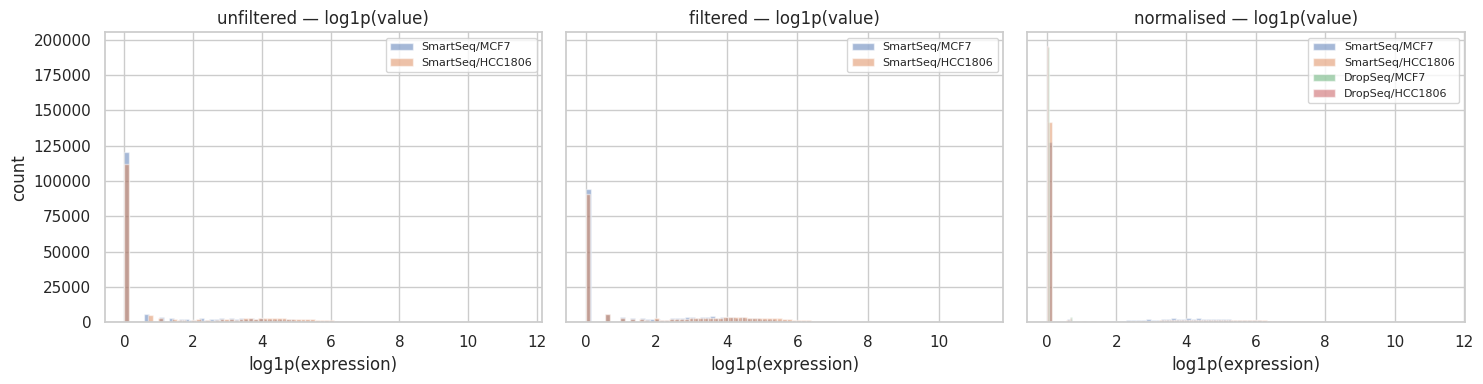

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, stage in zip(axes, ['unfiltered', 'filtered', 'normalised']):
    for (tech, line, s), df in matrices.items():
        if s != stage:
            continue
        sample = df.values.flatten()
        if sample.size > 200_000:
            sample = np.random.default_rng(SEED).choice(sample, 200_000, replace=False)
        ax.hist(np.log1p(sample), bins=80, alpha=0.5, label=f'{tech}/{line}')
    ax.set_title(f'{stage}, log1p(value)')
    ax.set_xlabel('log1p(expression)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('count')
plt.tight_layout()
plt.show()

### 4.3 Sparsity

scRNA-seq data is dominated by zeros (dropouts). We quantify the fraction of zeros per cell and per gene, and compare across technologies and preprocessing stages.

Expectation:
- **Unfiltered** has the most zeros.
- **DropSeq** is much sparser than **SmartSeq** at equivalent stages (DropSeq has shallower per-cell sequencing depth).
- **Filtered** and **Normalised** should reduce sparsity because zero-dominated rows and columns have been removed.

In [7]:
sparsity_rows = []
for (tech, line, stage), df in matrices.items():
    vals = df.values
    sparsity_rows.append({
        'technology': tech, 'cell_line': line, 'stage': stage,
        'overall_frac_zero': float((vals == 0).mean()),
        'median_frac_zero_per_cell': float(np.median((vals == 0).mean(axis=0))),
        'median_frac_zero_per_gene': float(np.median((vals == 0).mean(axis=1))),
    })
sparsity_df = pd.DataFrame(sparsity_rows).sort_values(['technology', 'cell_line', 'stage']).reset_index(drop=True)
sparsity_df

,technology,cell_line,stage,overall_frac_zero,median_frac_zero_per_cell,median_frac_zero_per_gene
0,DropSeq,HCC1806,normalised,0.976376,0.977667,0.996663
1,DropSeq,MCF7,normalised,0.975294,0.977000,0.995468
2,SmartSeq,HCC1806,filtered,0.452056,0.444598,0.414097
3,SmartSeq,HCC1806,normalised,0.706535,0.706167,0.879121
4,SmartSeq,HCC1806,unfiltered,0.558456,0.537058,0.617284
5,SmartSeq,MCF7,filtered,0.471576,0.461441,0.431310
6,SmartSeq,MCF7,normalised,0.636221,0.634333,0.784000
7,SmartSeq,MCF7,unfiltered,0.602153,0.568021,0.673629


### 4.4 Outliers, interquartile range (IQR)

For each cell we compute (a) **library size** = sum of counts, and (b) **detected genes** = number of non-zero entries. A value is flagged as an outlier if it lies outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`. We run this on the *unfiltered* SmartSeq data because that is where QC issues should be most visible.

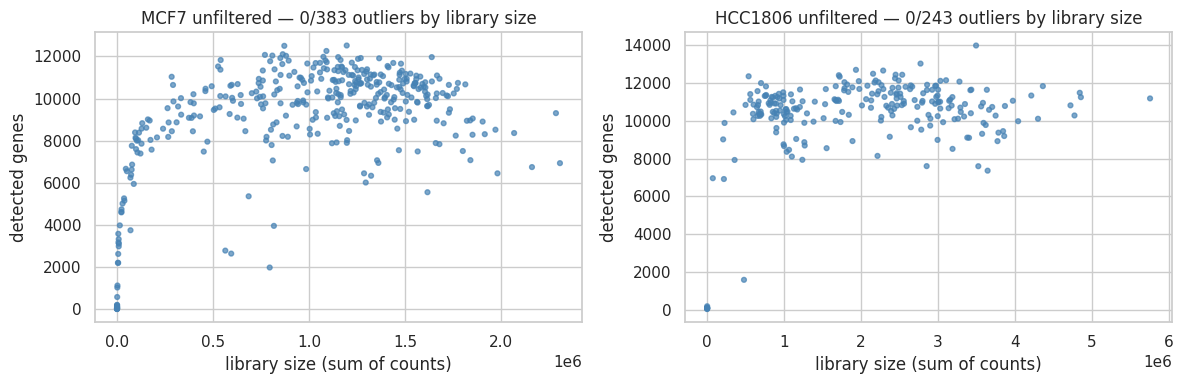

In [8]:
def iqr_flags(series: pd.Series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lo) | (series > hi), (lo, hi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, df) in zip(axes, [('MCF7 unfiltered', matrices[('SmartSeq', 'MCF7', 'unfiltered')]),
                                    ('HCC1806 unfiltered', matrices[('SmartSeq', 'HCC1806', 'unfiltered')])]):
    lib = df.sum(axis=0)
    detected = (df > 0).sum(axis=0)
    flagged, bounds = iqr_flags(lib)
    ax.scatter(lib, detected, c=np.where(flagged, 'red', 'steelblue'), s=12, alpha=0.7)
    ax.set_xlabel('library size (sum of counts)')
    ax.set_ylabel('detected genes')
    ax.set_title(f'{label}, {flagged.sum()}/{len(flagged)} outliers by library size')
plt.tight_layout()
plt.show()

### 4.5 Log transformation

Raw counts span orders of magnitude and have long right tails. The standard fix in RNA-seq is the `log1p` transform: `x → log(1 + x)`. The `+1` handles zeros, and the shape becomes much closer to bell-shaped, which makes it friendlier for most ML models (linear, SVM, MLP).

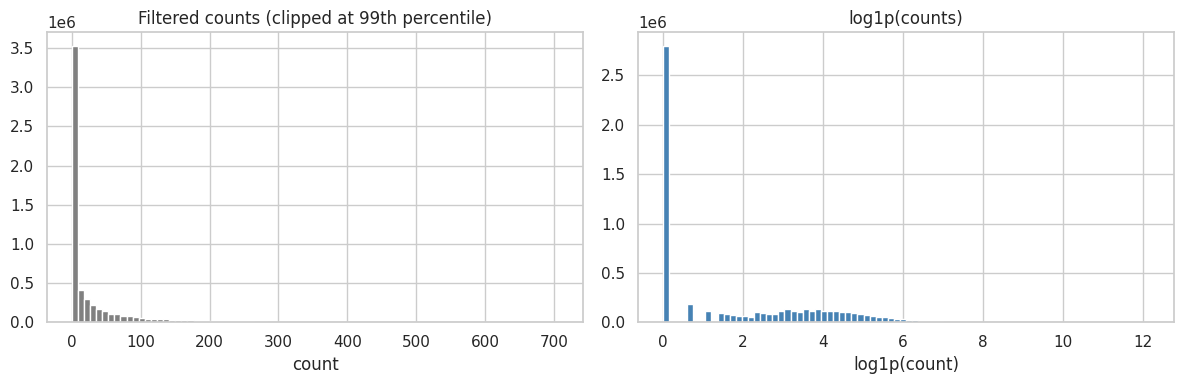

In [9]:
sample_df = matrices[('SmartSeq', 'MCF7', 'filtered')]
raw = sample_df.values.flatten()
logged = np.log1p(raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw < np.quantile(raw, 0.99)], bins=80, color='grey')
axes[0].set_title('Filtered counts (clipped at 99th percentile)')
axes[0].set_xlabel('count')
axes[1].hist(logged, bins=80, color='steelblue')
axes[1].set_title('log1p(counts)')
axes[1].set_xlabel('log1p(count)')
plt.tight_layout()
plt.show()

### 4.6 Duplicate rows

A duplicated gene row would mean the same gene appears twice in the matrix; a duplicated column would mean two cells have identical expression vectors (suspicious). We check both.

In [10]:
dup_rows = []
for (tech, line, stage), df in matrices.items():
    dup_rows.append({
        'technology': tech, 'cell_line': line, 'stage': stage,
        'dup_gene_rows': int(df.index.duplicated().sum()),
        'dup_cell_cols': int(df.columns.duplicated().sum()),
        'dup_gene_values': int(df.duplicated().sum()),
    })
pd.DataFrame(dup_rows)

,technology,cell_line,stage,dup_gene_rows,dup_cell_cols,dup_gene_values
0,SmartSeq,MCF7,unfiltered,0,0,29
1,SmartSeq,MCF7,filtered,0,0,5
2,SmartSeq,MCF7,normalised,0,0,1
3,SmartSeq,HCC1806,unfiltered,0,0,54
4,SmartSeq,HCC1806,filtered,0,0,16
5,SmartSeq,HCC1806,normalised,0,0,1
6,DropSeq,MCF7,normalised,0,0,0
7,DropSeq,HCC1806,normalised,0,0,0


## 5. Data structure

Here we move from per-value statistics to *relationships between* features (genes) and *between* samples (cells).

- **5.1 Correlation.** Gene-gene Pearson correlation on the top-variable genes, cell-cell on a subsample.
- **5.2 PCA.** We run PCA mostly to confirm what the course slides already warn: on single-cell expression data with strong sparsity, the first few PCs are often dominated by technical structure (library size, technology) rather than the biological signal we care about.
- **5.3 UMAP.** Non-linear dimensionality reduction, preferred over PCA here for visualisation. We colour the 2D embedding by condition, cell line and technology to see which axis the biology separates on.
- **5.4 Heatmap.** Top variable genes across condition, a quick visual for which genes look differentially expressed.

### 5.1 Gene-gene correlation

We compute the Pearson correlation matrix for the top 200 most variable genes of the SmartSeq MCF7 normalised matrix and cluster-order the rows/columns so correlation blocks become visible.

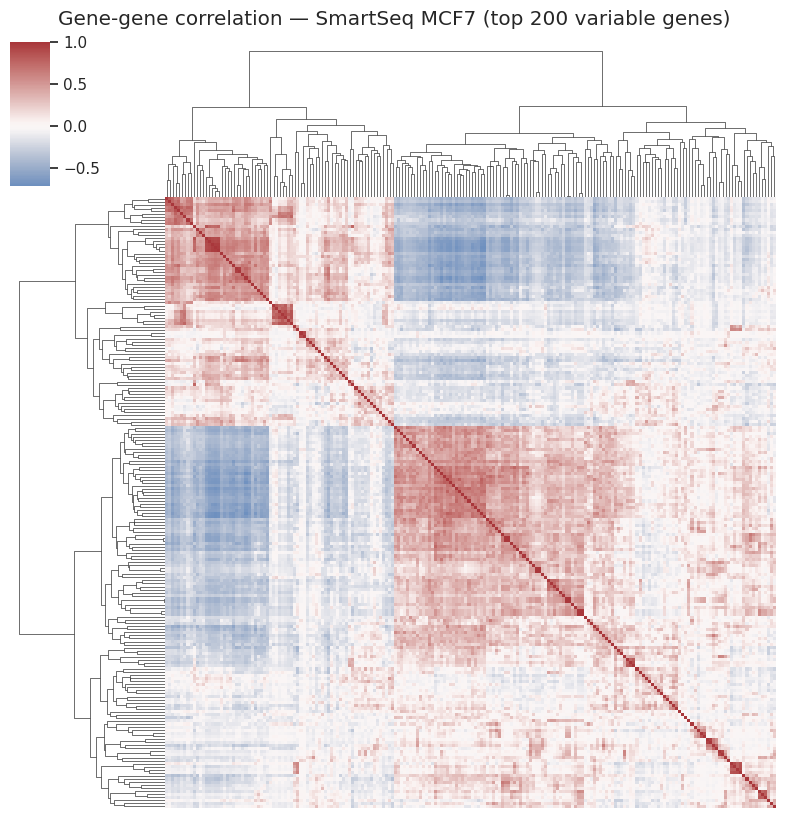

In [11]:
def prep_matrix(df):
    X = df.T.astype(float)
    return X

X_mcf7 = prep_matrix(matrices[('SmartSeq', 'MCF7', 'normalised')])
var_genes = X_mcf7.var(axis=0).nlargest(200).index
corr = X_mcf7[var_genes].corr()
g = sns.clustermap(corr, cmap='vlag', center=0, figsize=(8, 8),
                   xticklabels=False, yticklabels=False)
g.fig.suptitle('Gene-gene correlation, SmartSeq MCF7 (top 200 variable genes)', y=1.02)
plt.show()

### 5.2 PCA

We run PCA on the *combined* normalised data (all 4 subsets on the intersection of gene names) and plot the first two components coloured by condition and technology. A scree plot shows how much variance each component explains, with scRNA-seq we typically see a shallow curve, i.e. variance is spread across many directions, which is one reason UMAP is preferred for visualisation.

Shared genes across all 4 normalised subsets: 70


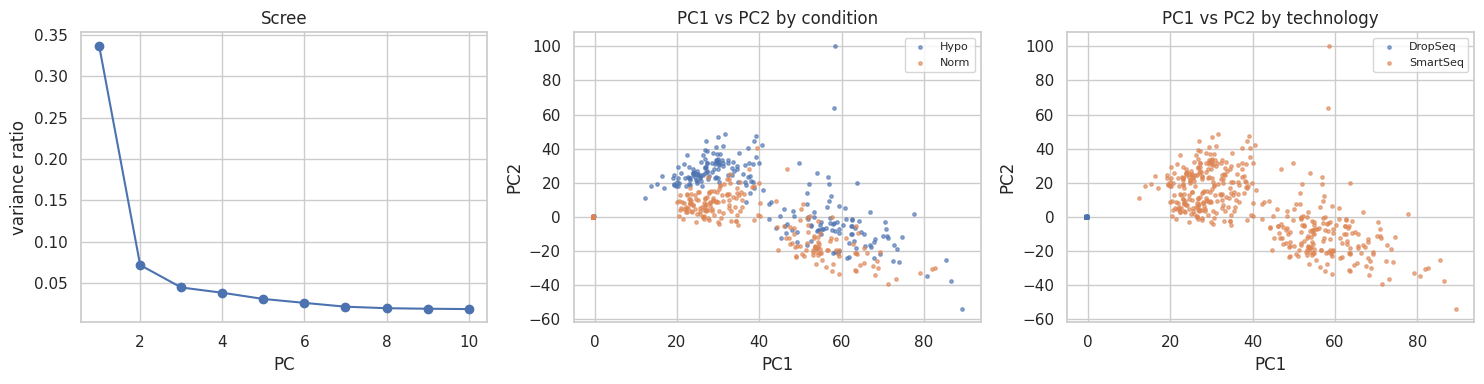

In [12]:
normalised_subsets = {(t, l): matrices[(t, l, 'normalised')] for t in ('SmartSeq', 'DropSeq') for l in ('MCF7', 'HCC1806')}
shared_genes = sorted(set.intersection(*(set(df.index) for df in normalised_subsets.values())))
print(f'Shared genes across all 4 normalised subsets: {len(shared_genes)}')

pieces = []
for (tech, line), df in normalised_subsets.items():
    sub = df.loc[shared_genes].T.copy()
    sub['technology'] = tech
    sub['cell_line'] = line
    sub['cell_id'] = sub.index
    pieces.append(sub)
combined = pd.concat(pieces, ignore_index=True)
combined = combined.merge(meta[['cell_id', 'condition']].drop_duplicates('cell_id'), on='cell_id', how='left')

X = combined[shared_genes].values
Xs = StandardScaler().fit_transform(X)
pca = PCA(n_components=10, random_state=SEED).fit(Xs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(np.arange(1, 11), pca.explained_variance_ratio_, marker='o')
axes[0].set_title('Scree'); axes[0].set_xlabel('PC'); axes[0].set_ylabel('variance ratio')

emb = pca.transform(Xs)
for ax, colour_by in zip(axes[1:], ['condition', 'technology']):
    for val, sub in combined.groupby(colour_by):
        idx = sub.index.values
        ax.scatter(emb[idx, 0], emb[idx, 1], s=6, alpha=0.6, label=str(val))
    ax.legend(fontsize=8)
    ax.set_title(f'PC1 vs PC2 by {colour_by}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

### 5.3 UMAP

We feed UMAP the first 30 PCs (a common recipe: PCA as a denoiser, UMAP for the non-linear layout). Three copies coloured by condition, cell line and technology tell us which factor dominates the global structure.

UMAP backend: cuML (GPU)


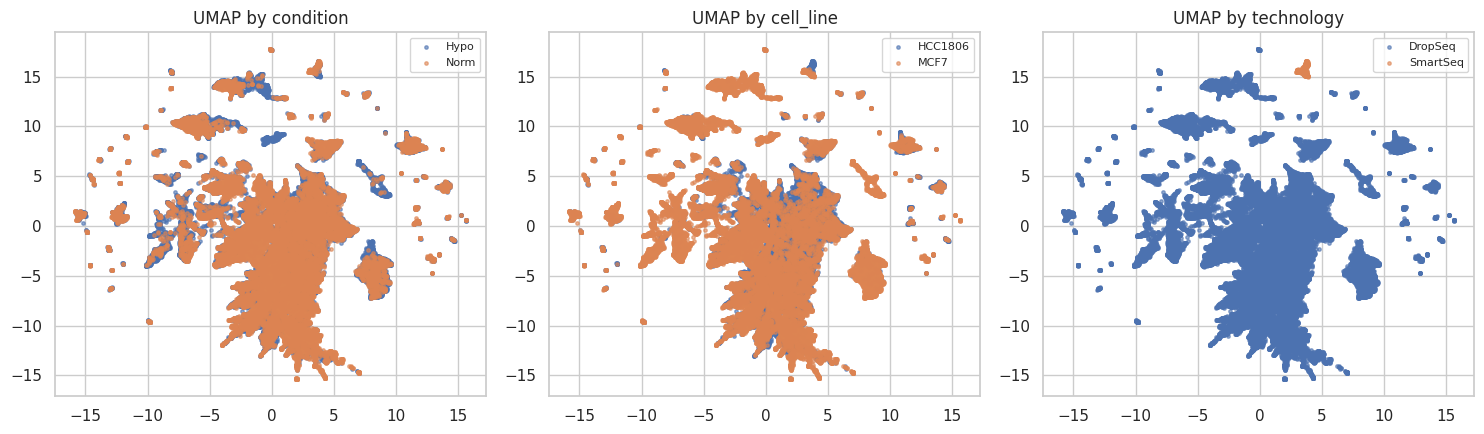

In [13]:
if UMAP_OK:
    n_pcs = min(30, Xs.shape[1] - 1)
    emb_pcs = PCA(n_components=n_pcs, random_state=SEED).fit_transform(Xs)
    try:
        from cuml.manifold import UMAP as _cuUMAP
        reducer = _cuUMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.3)
        _umap_backend = 'cuML (GPU)'
    except Exception as _e:
        reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.3)
        _umap_backend = f'umap-learn (CPU) - cuML unavailable: {type(_e).__name__}'
    u = np.asarray(reducer.fit_transform(emb_pcs))
    print('UMAP backend:', _umap_backend)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, colour_by in zip(axes, ['condition', 'cell_line', 'technology']):
        for val, sub in combined.groupby(colour_by):
            idx = sub.index.values
            ax.scatter(u[idx, 0], u[idx, 1], s=6, alpha=0.6, label=str(val))
        ax.legend(fontsize=8)
        ax.set_title(f'UMAP by {colour_by}')
    plt.tight_layout()
    plt.show()
else:
    print('umap-learn not installed; skipping UMAP.')


### 5.4 Heatmap of top variable genes by condition

A quick check that *some* genes look differentially expressed between Hypo and Norm within a single cell-line/technology subset.

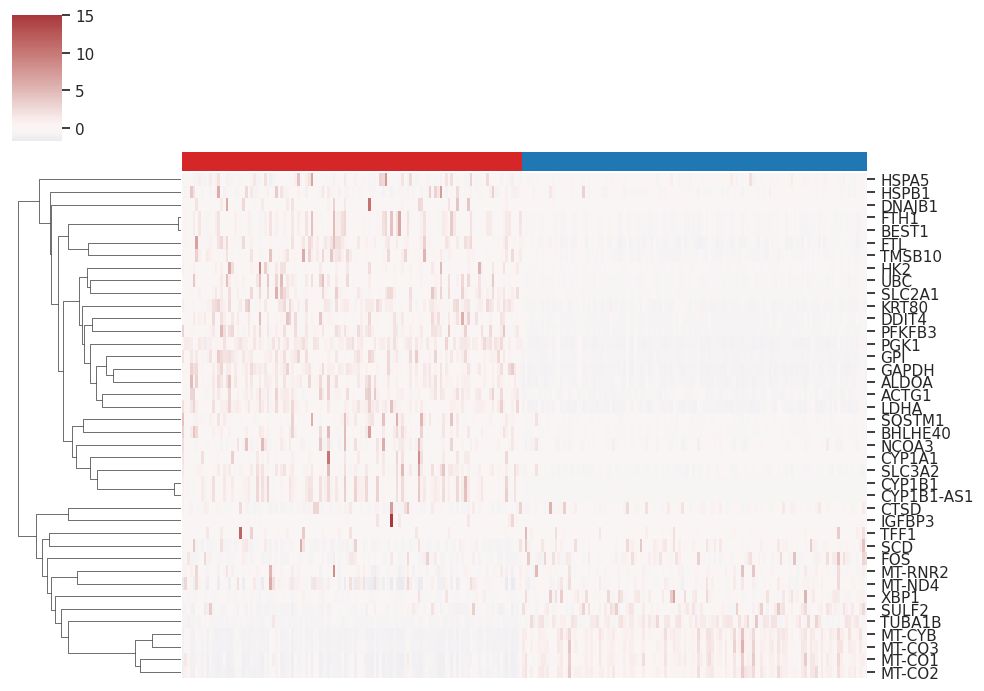

In [14]:
target = matrices[('SmartSeq', 'MCF7', 'normalised')]
labels = labels_by_cell.reindex(target.columns)
sub = target.loc[target.var(axis=1).nlargest(40).index]
col_order = labels.sort_values().index
sub = sub[col_order]
colour_map = labels.reindex(col_order).map({'Hypo': '#d62728', 'Norm': '#1f77b4'})
sns.clustermap(sub, col_cluster=False, z_score=0, cmap='vlag', center=0, figsize=(10, 7),
               col_colors=colour_map.values, yticklabels=True, xticklabels=False)
plt.show()

## 6. Unsupervised learning

We skip K-means (by group decision) and use **hierarchical clustering** as our clustering baseline, plus **autoencoders** (vanilla + denoising) as unsupervised feature learners whose bottleneck we then feed to a supervised classifier in section 7.

### 6.1 Hierarchical clustering

Ward linkage on a correlation distance, computed on cells (not genes), inside one subset. We check how well the two-cluster cut aligns with the hypoxia label using the Adjusted Rand Index.

In [15]:
from sklearn.metrics import adjusted_rand_score

try:
    import cupy as _cp
    _HAS_CUPY = True
except Exception:
    _HAS_CUPY = False

def _corr_pdist(X):
    # Correlation-distance condensed pdist; uses GPU via cupy if available, else scipy.
    # correlation_dist(u,v) = 1 - <u - mean(u), v - mean(v)> / (||u - mean(u)|| * ||v - mean(v)||)
    if _HAS_CUPY:
        Xc = _cp.asarray(X, dtype=_cp.float32)
        Xc = Xc - Xc.mean(axis=1, keepdims=True)
        norms = _cp.linalg.norm(Xc, axis=1, keepdims=True)
        Xc = Xc / _cp.maximum(norms, 1e-12)
        D = 1.0 - Xc @ Xc.T
        N = D.shape[0]
        iu = _cp.triu_indices(N, k=1)
        cond = _cp.asnumpy(D[iu]).astype('float64')
        del Xc, D
        _cp.get_default_memory_pool().free_all_blocks()
        return cond
    return pdist(X, metric='correlation')

def hier_cluster_eval(tech, line, k=2):
    df = matrices[(tech, line, 'normalised')]
    X = df.T.values
    y = labels_by_cell.reindex(df.columns).values
    dist = _corr_pdist(X)
    Z = linkage(dist, method='average')
    clusters = fcluster(Z, t=k, criterion='maxclust')
    ari = adjusted_rand_score(y, clusters)
    return ari, clusters, y

print('pdist backend:', 'cupy (GPU)' if _HAS_CUPY else 'scipy (CPU)')
for tech in ('SmartSeq', 'DropSeq'):
    for line in ('MCF7', 'HCC1806'):
        ari, _, _ = hier_cluster_eval(tech, line)
        print(f'{tech:8s} {line:8s}  ARI(condition vs 2-cluster cut) = {ari:.3f}')


pdist backend: cupy (GPU)
SmartSeq MCF7      ARI(condition vs 2-cluster cut) = 0.000
SmartSeq HCC1806   ARI(condition vs 2-cluster cut) = -0.001
DropSeq  MCF7      ARI(condition vs 2-cluster cut) = 0.000
DropSeq  HCC1806   ARI(condition vs 2-cluster cut) = 0.000


### 6.2 Autoencoder and denoising autoencoder

Small fully-connected AE: `3000 → 256 → 32 → 256 → 3000`, MSE reconstruction. The **denoising** variant corrupts the input with 30% Bernoulli dropout during training, the encoder then learns features robust to that noise. We run both on the shared genes of the normalised data and save the 32-dim bottleneck for use as features later.

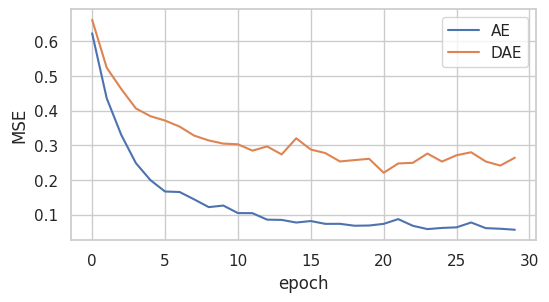

In [16]:
def train_ae(X, latent=32, denoising=False, dropout_p=0.3, epochs=40, lr=1e-3, batch=256):
    if not TORCH_OK:
        return None, None, None
    device = DEVICE
    use_amp = (device.type == 'cuda')
    n_in = X.shape[1]

    class AE(nn.Module):
        def __init__(self):
            super().__init__()
            self.enc = nn.Sequential(nn.Linear(n_in, 256), nn.ReLU(), nn.Linear(256, latent))
            self.dec = nn.Sequential(nn.Linear(latent, 256), nn.ReLU(), nn.Linear(256, n_in))
        def forward(self, x):
            z = self.enc(x)
            return self.dec(z), z

    model = AE().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    Xt = torch.tensor(np.asarray(X), dtype=torch.float32, device=device)
    n = Xt.shape[0]

    losses = []
    for ep in range(epochs):
        perm = torch.randperm(n, device=device)
        ep_loss = 0.0
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            xb = Xt[idx]
            noisy = xb if not denoising else xb * (torch.rand_like(xb) > dropout_p)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                recon, _ = model(noisy)
                loss = loss_fn(recon, xb)
            loss.backward()
            opt.step()
            ep_loss += float(loss.detach()) * xb.size(0)
        losses.append(ep_loss / n)

    model.eval()
    with torch.no_grad():
        _, Z = model(Xt)
        Z = Z.detach().cpu().numpy()
    return model, Z, losses

if TORCH_OK:
    X_shared = combined[shared_genes].values.astype('float32')
    X_shared = np.asarray(StandardScaler().fit_transform(X_shared))
    _, Z_vanilla, loss_v = train_ae(X_shared, denoising=False, epochs=30)
    _, Z_denoise, loss_d = train_ae(X_shared, denoising=True,  epochs=30)
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(loss_v, label='AE')
    ax.plot(loss_d, label='DAE')
    ax.set_xlabel('epoch'); ax.set_ylabel('MSE'); ax.legend()
    plt.show()
else:
    print('PyTorch not installed - AE section skipped.')
    Z_vanilla = Z_denoise = None


## 7. Supervised classification

We now predict `Hypo` vs `Norm` from gene expression.

**Evaluation harness.** Every classifier is scored with **Stratified 5-fold CV** on ROC-AUC, accuracy and F1. ROC-AUC is the primary metric because classes can be imbalanced inside individual subsets.

**Pipeline per fold.** `StandardScaler → classifier`. The scaler is fit only on the training fold to avoid leakage.

**Classifiers in scope.** LASSO (L1 logistic), Random Forest, Linear SVM, MLP, AE-features + logistic regression, 1D CNN.

In [17]:
def make_Xy(tech, line):
    df = matrices[(tech, line, 'normalised')]
    y = labels_by_cell.reindex(df.columns)
    mask = y.isin(['Hypo', 'Norm']).values
    X = df.T.values[mask]
    y = (y[mask] == 'Hypo').astype(int).values
    genes = df.index.values
    return X, y, genes

def cv_score(clf, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    scores = cross_validate(
        Pipeline([('sc', StandardScaler()), ('clf', clf)]),
        X, y, cv=skf,
        scoring=['roc_auc', 'accuracy', 'f1'],
        return_train_score=False,
    )
    return {k.replace('test_', ''): float(np.mean(v)) for k, v in scores.items() if k.startswith('test_')}

SUBSETS = [('SmartSeq', 'MCF7'), ('SmartSeq', 'HCC1806'), ('DropSeq', 'MCF7'), ('DropSeq', 'HCC1806')]
Xys = {s: make_Xy(*s) for s in SUBSETS}
for s, (X, y, _) in Xys.items():
    print(f'{s}: X={X.shape}, class balance={np.bincount(y)}')

('SmartSeq', 'MCF7'): X=(250, 3000), class balance=[126 124]
('SmartSeq', 'HCC1806'): X=(182, 3000), class balance=[85 97]
('DropSeq', 'MCF7'): X=(21626, 3000), class balance=[12705  8921]
('DropSeq', 'HCC1806'): X=(14682, 3000), class balance=[5783 8899]


### 7.1 LASSO (L1 logistic regression)

We use `GridSearchCV` over `LogisticRegression(penalty='l1', solver='saga')` to pick the regularisation strength `C` from a 20-point log grid via 3-fold inner CV. This is equivalent to `LogisticRegressionCV` but goes through the `cuml.accel`-proxied `LogisticRegression`, so the fits run on GPU. L1 drives most coefficients to zero, the non-zero ones are the genes LASSO found useful for discriminating Hypo vs Norm.

We record stability: a gene selected in every fold matters more than one selected once.

In [18]:
LASSO_CS = np.logspace(-4, 4, 20)

def lasso_fit(X, y, genes):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    selected = np.zeros(X.shape[1], dtype=int)
    aucs = []
    for tr, te in skf.split(X, y):
        sc = StandardScaler().fit(X[tr])
        Xtr = sc.transform(X[tr]).astype('float32')
        Xte = sc.transform(X[te]).astype('float32')
        gs = GridSearchCV(
            LogisticRegression(penalty='l1', solver='saga', max_iter=3000, random_state=SEED),
            {'C': LASSO_CS}, cv=3, scoring='roc_auc', n_jobs=1,
        ).fit(Xtr, y[tr])
        clf = gs.best_estimator_
        prob = clf.predict_proba(Xte)[:, 1]
        aucs.append(roc_auc_score(y[te], prob))
        selected += (clf.coef_[0] != 0).astype(int)
    stability = pd.Series(selected / 5, index=genes).sort_values(ascending=False)
    return float(np.mean(aucs)), stability

lasso_results = {}
for subset, (X, y, g) in Xys.items():
    auc, stab = lasso_fit(X, y, g)
    lasso_results[subset] = {'auc': auc, 'top_genes': stab.head(20)}
    print(f'LASSO {subset}: AUC={auc:.3f}, non-zero (>=80% folds) = {(stab >= 0.8).sum()}')

print('\nTop stable genes for SmartSeq/MCF7:')
print(lasso_results[('SmartSeq', 'MCF7')]['top_genes'].head(15))

LASSO ('SmartSeq', 'MCF7'): AUC=1.000, non-zero (>=80% folds) = 6
LASSO ('SmartSeq', 'HCC1806'): AUC=0.992, non-zero (>=80% folds) = 12
[2026-04-25 09:37:03.230] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-25 09:37:04.967] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-25 09:37:26.182] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-25 09:37:49.021] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-25 09:37:49.412] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-25 09:37:50.789] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-25 09:38:13.590] [CUML] [warning] QWL-QN line search failed (code 3); stopping at the last valid step
[20

### 7.2 Random Forest

300 trees, balanced class weight. Non-linear, handles high-dimensional input without scaling, but we still standardise for consistency with the pipeline.

In [19]:
rf_results = {}
for subset, (X, y, g) in Xys.items():
    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                n_jobs=-1, random_state=SEED)
    rf_results[subset] = cv_score(rf, X, y)
    print(f'RF {subset}: AUC={rf_results[subset]["roc_auc"]:.3f}  Acc={rf_results[subset]["accuracy"]:.3f}  F1={rf_results[subset]["f1"]:.3f}')

RF ('SmartSeq', 'MCF7'): AUC=1.000  Acc=0.996  F1=0.996
RF ('SmartSeq', 'HCC1806'): AUC=0.999  Acc=0.989  F1=0.990
RF ('DropSeq', 'MCF7'): AUC=0.995  Acc=0.968  F1=0.960
RF ('DropSeq', 'HCC1806'): AUC=0.990  Acc=0.939  F1=0.952


### 7.3 Linear SVM

`LinearSVC` with default C. It is a non-probabilistic classifier, so to get ROC-AUC we wrap it in `CalibratedClassifierCV` which fits a sigmoid on top of the margin.

In [20]:
svm_results = {}
for subset, (X, y, g) in Xys.items():
    base = LinearSVC(C=1.0, random_state=SEED, max_iter=5000)
    clf = CalibratedClassifierCV(base, cv=3)
    svm_results[subset] = cv_score(clf, X, y)
    print(f'SVM {subset}: AUC={svm_results[subset]["roc_auc"]:.3f}  Acc={svm_results[subset]["accuracy"]:.3f}')

SVM ('SmartSeq', 'MCF7'): AUC=1.000  Acc=1.000
SVM ('SmartSeq', 'HCC1806'): AUC=0.995  Acc=0.956
SVM ('DropSeq', 'MCF7'): AUC=0.995  Acc=0.971
SVM ('DropSeq', 'HCC1806'): AUC=0.980  Acc=0.927


### 7.4 MLP classifier

Two hidden layers (128, 32). Early stopping on a 10% validation slice of the training fold.

In [21]:
def _torch_mlp_fold(Xtr, ytr, Xte, yte, hidden=(128, 32),
                    epochs=300, batch=256, val_frac=0.1, patience=15,
                    lr=1e-3, seed=SEED):
    device = DEVICE
    use_amp = (device.type == 'cuda')
    rng = np.random.RandomState(seed)
    n_val = max(1, int(len(Xtr) * val_frac))
    perm = rng.permutation(len(Xtr))
    vi, ti = perm[:n_val], perm[n_val:]

    class MLP(nn.Module):
        def __init__(self, n_in, hidden):
            super().__init__()
            layers, prev = [], n_in
            for h in hidden:
                layers += [nn.Linear(prev, h), nn.ReLU()]
                prev = h
            layers += [nn.Linear(prev, 2)]
            self.net = nn.Sequential(*layers)
        def forward(self, x):
            return self.net(x)

    torch.manual_seed(seed)
    model = MLP(Xtr.shape[1], hidden).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    Xtr_t = torch.tensor(np.asarray(Xtr)[ti], dtype=torch.float32, device=device)
    ytr_t = torch.tensor(np.asarray(ytr)[ti], dtype=torch.long,    device=device)
    Xv_t  = torch.tensor(np.asarray(Xtr)[vi], dtype=torch.float32, device=device)
    yv_t  = torch.tensor(np.asarray(ytr)[vi], dtype=torch.long,    device=device)
    Xte_t = torch.tensor(np.asarray(Xte),     dtype=torch.float32, device=device)

    n = Xtr_t.shape[0]
    best_val, best_state, bad = float('inf'), None, 0
    for _ in range(epochs):
        model.train()
        order = torch.randperm(n, device=device)
        for i in range(0, n, batch):
            idx = order[i:i+batch]
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                loss = loss_fn(model(Xtr_t[idx]), ytr_t[idx])
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
            v = float(loss_fn(model(Xv_t), yv_t))
        if v < best_val - 1e-4:
            best_val = v
            best_state = {k: t.detach().clone() for k, t in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        prob = torch.softmax(model(Xte_t).float(), dim=1).cpu().numpy()[:, 1]
    pred = (prob >= 0.5).astype(int)
    return roc_auc_score(yte, prob), accuracy_score(yte, pred), f1_score(yte, pred)

mlp_results = {}
for subset, (X, y, g) in Xys.items():
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    aucs, accs, f1s = [], [], []
    for tr, te in skf.split(X, y):
        sc = StandardScaler().fit(X[tr])
        Xtr = np.asarray(sc.transform(X[tr])).astype('float32')
        Xte = np.asarray(sc.transform(X[te])).astype('float32')
        a, b, c = _torch_mlp_fold(Xtr, y[tr], Xte, y[te])
        aucs.append(a); accs.append(b); f1s.append(c)
    mlp_results[subset] = {'roc_auc': float(np.mean(aucs)),
                           'accuracy': float(np.mean(accs)),
                           'f1': float(np.mean(f1s))}
    print(f'MLP {subset}: AUC={mlp_results[subset]["roc_auc"]:.3f}  Acc={mlp_results[subset]["accuracy"]:.3f}')


MLP ('SmartSeq', 'MCF7'): AUC=1.000  Acc=0.992
MLP ('SmartSeq', 'HCC1806'): AUC=0.963  Acc=0.901
MLP ('DropSeq', 'MCF7'): AUC=0.995  Acc=0.969
MLP ('DropSeq', 'HCC1806'): AUC=0.983  Acc=0.937


### 7.5 1D CNN

Small PyTorch model: `Conv1d(1→16, kernel=7) → Conv1d(16→16, kernel=7) → AvgPool → Linear(→2)`. Genes are input in decreasing-variance order (an arbitrary but reproducible 1D ordering, since we have no chromosomal coordinates).

In [22]:
def train_cnn_fold(Xtr, ytr, Xte, yte, epochs=25, batch=256, lr=1e-3, seed=SEED):
    device = DEVICE
    use_amp = (device.type == 'cuda')

    class CNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv1d(1, 16, kernel_size=7, padding=3), nn.ReLU(),
                nn.Conv1d(16, 16, kernel_size=7, padding=3), nn.ReLU(),
                nn.AdaptiveAvgPool1d(64), nn.Flatten(),
                nn.Linear(16 * 64, 32), nn.ReLU(),
                nn.Linear(32, 2))
        def forward(self, x):
            return self.net(x)

    torch.manual_seed(seed)
    model = CNN().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    Xtr_t = torch.tensor(np.asarray(Xtr), dtype=torch.float32, device=device).unsqueeze(1)
    ytr_t = torch.tensor(np.asarray(ytr), dtype=torch.long,    device=device)
    Xte_t = torch.tensor(np.asarray(Xte), dtype=torch.float32, device=device).unsqueeze(1)

    n = Xtr_t.shape[0]
    for _ in range(epochs):
        model.train()
        order = torch.randperm(n, device=device)
        for i in range(0, n, batch):
            idx = order[i:i+batch]
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                loss = loss_fn(model(Xtr_t[idx]), ytr_t[idx])
            loss.backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        prob = torch.softmax(model(Xte_t).float(), dim=1).cpu().numpy()[:, 1]
    return roc_auc_score(yte, prob)

cnn_results = {}
if TORCH_OK:
    for subset, (X, y, g) in Xys.items():
        order = np.argsort(-X.var(axis=0))
        Xo = X[:, order]
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        aucs = []
        for tr, te in skf.split(Xo, y):
            sc = StandardScaler().fit(Xo[tr])
            Xtr = np.asarray(sc.transform(Xo[tr])).astype('float32')
            Xte = np.asarray(sc.transform(Xo[te])).astype('float32')
            aucs.append(train_cnn_fold(Xtr, y[tr], Xte, y[te]))
        cnn_results[subset] = {'roc_auc': float(np.mean(aucs))}
        print(f'1D CNN {subset}: AUC={cnn_results[subset]["roc_auc"]:.3f}')
else:
    print('PyTorch not installed - 1D CNN section skipped.')


1D CNN ('SmartSeq', 'MCF7'): AUC=0.852
1D CNN ('SmartSeq', 'HCC1806'): AUC=0.728
1D CNN ('DropSeq', 'MCF7'): AUC=0.946
1D CNN ('DropSeq', 'HCC1806'): AUC=0.763


### 7.6 Autoencoder features → logistic regression

We reuse the bottleneck representation `Z_vanilla` (and `Z_denoise`) learned in §6.2 and train a simple logistic regression on top, per subset.

In [23]:
ae_results = {}
if TORCH_OK and Z_vanilla is not None:
    for subset, _ in Xys.items():
        tech, line = subset
        mask = ((combined['technology'] == tech) &
                (combined['cell_line']  == line) &
                (combined['condition'].isin(['Hypo', 'Norm']))).values
        Zv = Z_vanilla[mask]
        Zd = Z_denoise[mask]
        y_bin = (combined.loc[mask, 'condition'] == 'Hypo').astype(int).values
        res_v = cv_score(LogisticRegression(max_iter=2000, random_state=SEED), Zv, y_bin)
        res_d = cv_score(LogisticRegression(max_iter=2000, random_state=SEED), Zd, y_bin)
        ae_results[subset] = {'AE':  res_v['roc_auc'], 'DAE': res_d['roc_auc']}
        print(f'AE/DAE features {subset}: AUC_AE={res_v["roc_auc"]:.3f}  AUC_DAE={res_d["roc_auc"]:.3f}')
else:
    print('PyTorch not installed or AE not trained - AE-features section skipped.')


AE/DAE features ('SmartSeq', 'MCF7'): AUC_AE=1.000  AUC_DAE=0.999
AE/DAE features ('SmartSeq', 'HCC1806'): AUC_AE=0.917  AUC_DAE=0.967
AE/DAE features ('DropSeq', 'MCF7'): AUC_AE=0.885  AUC_DAE=0.865
AE/DAE features ('DropSeq', 'HCC1806'): AUC_AE=0.679  AUC_DAE=0.687


### 7.7 Comparison across classifiers

One table per subset, one column per classifier (AUC). A useful sanity check: within-subset AUC is almost always high on this kind of data. The honest test comes in §8 (cross-subset).

In [24]:
compare = {}
for subset in SUBSETS:
    row = {'LASSO': lasso_results[subset]['auc'],
           'RF':    rf_results[subset]['roc_auc'],
           'SVM':   svm_results[subset]['roc_auc'],
           'MLP':   mlp_results[subset]['roc_auc']}
    if subset in cnn_results: row['1D CNN'] = cnn_results[subset]['roc_auc']
    if subset in ae_results:  row['AE-feat'] = ae_results[subset]['AE']
    if subset in ae_results:  row['DAE-feat'] = ae_results[subset]['DAE']
    compare[f'{subset[0]}/{subset[1]}'] = row
compare_df = pd.DataFrame(compare).T
compare_df.style.background_gradient(cmap='Blues').format('{:.3f}')

,LASSO,RF,SVM,MLP,1D CNN,AE-feat,DAE-feat
SmartSeq/MCF7,1.000,1.000,1.000,1.000,0.852,1.000,0.999
SmartSeq/HCC1806,0.992,0.999,0.995,0.963,0.728,0.917,0.967
DropSeq/MCF7,0.997,0.995,0.995,0.995,0.946,0.885,0.865
DropSeq/HCC1806,0.990,0.990,0.980,0.983,0.763,0.679,0.687


## 8. Cross-cell-line and cross-technology generalisation

This is the most important experiment in the report. Within each subset, the classifier almost certainly gets very high AUC, but that does *not* mean we found a biological hypoxia signature; it might just mean the model memorised the batch.

We now train on one (cell-line, technology) subset and evaluate on a different one. To do that we must restrict both matrices to the *intersection* of their gene sets. We run this for **LASSO** (interpretable baseline) and **Random Forest** (non-linear baseline). If AUC stays high across subsets, the signature generalises; if it collapses, the classifier was fitting technology/cell-line artefacts.

In [25]:
def cross_eval(src, dst, model_fn):
    df_s = matrices[(src[0], src[1], 'normalised')]
    df_d = matrices[(dst[0], dst[1], 'normalised')]
    shared = sorted(set(df_s.index) & set(df_d.index))
    y_s = labels_by_cell.loc[df_s.columns]
    y_d = labels_by_cell.loc[df_d.columns]
    ms = y_s.isin(['Hypo', 'Norm']).values
    md = y_d.isin(['Hypo', 'Norm']).values
    Xs = df_s.loc[shared].T.values[ms]
    Xd = df_d.loc[shared].T.values[md]
    ys = (y_s[ms] == 'Hypo').astype(int).values
    yd = (y_d[md] == 'Hypo').astype(int).values
    sc = StandardScaler().fit(Xs)
    clf = model_fn().fit(sc.transform(Xs).astype('float32'), ys)
    Xd_t = sc.transform(Xd).astype('float32')
    if hasattr(clf, 'predict_proba'):
        prob = clf.predict_proba(Xd_t)[:, 1]
    else:
        prob = clf.decision_function(Xd_t)
    return roc_auc_score(yd, prob), len(shared)

def make_lasso_gs():
    return GridSearchCV(
        LogisticRegression(penalty='l1', solver='saga', max_iter=2000, random_state=SEED),
        {'C': np.logspace(-3, 3, 10)}, cv=3, scoring='roc_auc', n_jobs=1,
    )

models = {
    'LASSO': make_lasso_gs,
    'RF':    lambda: RandomForestClassifier(n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=SEED),
}

rows = []
for name, mfn in models.items():
    for src in SUBSETS:
        for dst in SUBSETS:
            if src == dst:
                continue
            auc, n_shared = cross_eval(src, dst, mfn)
            rows.append({'model': name,
                         'train': f'{src[0]}/{src[1]}',
                         'test':  f'{dst[0]}/{dst[1]}',
                         'n_shared_genes': n_shared,
                         'auc': auc})
gen_df = pd.DataFrame(rows)
for name in models:
    pivot = gen_df[gen_df.model == name].pivot(index='train', columns='test', values='auc')
    print(f'\n== {name} cross-subset AUC ==')
    print(pivot.round(3))

[2026-04-25 09:44:44.350] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-25 09:44:45.238] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-25 09:44:53.842] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-25 09:44:57.130] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-25 09:44:57.224] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-25 09:44:57.746] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)

== LASSO cross-subset AUC ==
test              DropSeq/HCC1806  DropSeq/MCF7  SmartSeq/HCC1806  SmartSeq/MCF7
train                                                                           
DropSeq/HCC1806               NaN         0.791           

## 9. Prediction on unseen (anonymised) test data

The course provides `*_test_anonim.txt` files for both technologies and both cell lines. Their columns are renumbered so we cannot see the hypoxia labels. We use our best in-subset classifier (LASSO) to produce predictions and save them as a tab-separated file the course can grade against the hidden labels.

> Note: if the test set is released later with a different schema, only the loading step changes.

In [26]:
test_paths = {
    ('SmartSeq', 'MCF7'):    SMART / 'MCF7_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt',
    ('SmartSeq', 'HCC1806'): SMART / 'HCC1806_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt',
    ('DropSeq',  'MCF7'):    DROP  / 'MCF7_Filtered_Normalised_3000_Data_test_anonim.txt',
    ('DropSeq',  'HCC1806'): DROP  / 'HCC1806_Filtered_Normalised_3000_Data_test_anonim.csv',
}

pred_frames = []
for subset, path in test_paths.items():
    if not path.exists():
        print(f'[skip] {path.name} missing')
        continue
    X_tr, y_tr, g_tr = Xys[subset]
    sc = StandardScaler().fit(X_tr)
    Xtr_t = sc.transform(X_tr).astype('float32')
    clf = GridSearchCV(
        LogisticRegression(penalty='l1', solver='saga', max_iter=3000, random_state=SEED),
        {'C': np.logspace(-3, 3, 10)}, cv=3, scoring='roc_auc', n_jobs=1,
    ).fit(Xtr_t, y_tr).best_estimator_
    test_df = load_expr(path)
    shared = [g for g in g_tr if g in test_df.index]
    if len(shared) < len(g_tr):
        missing = [g for g in g_tr if g not in test_df.index]
        fill = pd.DataFrame(0.0, index=missing, columns=test_df.columns)
        test_df = pd.concat([test_df, fill]).loc[g_tr]
    else:
        test_df = test_df.loc[g_tr]
    Xte = sc.transform(test_df.T.values).astype('float32')
    prob = clf.predict_proba(Xte)[:, 1]
    pred = pd.DataFrame({'cell_id': test_df.columns,
                         'technology': subset[0], 'cell_line': subset[1],
                         'prob_hypo': prob,
                         'pred': np.where(prob >= 0.5, 'Hypo', 'Norm')})
    pred_frames.append(pred)

if pred_frames:
    predictions = pd.concat(pred_frames, ignore_index=True)
    predictions.to_csv(OUT_DIR / 'predictions.tsv', sep='\t', index=False)
    print(f'Wrote {len(predictions)} predictions to {(OUT_DIR / "predictions.tsv").resolve()}')
    predictions.head()
else:
    print('No test files found on disk.')

[2026-04-25 09:45:25.991] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-25 09:45:26.191] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
Wrote 9185 predictions to /mnt/c/Users/ricca/OneDrive/universita/4_semestre/AI_lab/ai-lab-gene-expression/outputs/predictions.tsv


## 10. Conclusions and next steps

*(Fill in after first full run.)*

Expected take-aways, given the literature and the course slides:
1. Within-subset AUC will be very high for every model, unsurprising, and not by itself evidence of a biomarker.
2. Cross-technology AUC (SmartSeq ↔ DropSeq) will likely be markedly lower than within-technology, because technical batch effects dominate PC1–PC2.
3. Cross-cell-line AUC within the same technology is the most honest test: if LASSO genes learned on MCF7/SmartSeq still score well on HCC1806/SmartSeq, those genes are promising hypoxia biomarker candidates. The stable LASSO gene list should overlap with the canonical HIF-target programme (VEGFA, CA9, SLC2A1, LDHA, BNIP3, PDK1, …).
4. The autoencoder-based features and the 1D CNN are expected to be competitive but not dominant, the sample size inside each subset is small.